<a href="https://colab.research.google.com/github/jimitxdave/Jimit_INFO5731_Spring2026/blob/main/Dave_Jimit_Assignment_02_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


In [2]:
import pandas as pd

df = pd.read_csv('semantic_scholar_data.csv')
df = df.head(100)
documents = df['abstract'].dropna().tolist()

print(f"✅ Loaded {len(documents)} abstracts")

✅ Loaded 100 abstracts


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [3]:
# ============================================================
# QUESTION 1 - COMPLETE (All 3 Parts)
# ============================================================

import pandas as pd
import spacy

# ── Load Data ──────────────────────────────────────────────
df = pd.read_csv('semantic_scholar_data.csv')
df = df.head(100)
documents = df['abstract'].dropna().tolist()
print(f"✅ Loaded {len(documents)} abstracts")

# ============================================================
# PART 1: Count Bigrams (N=2) and Trigrams (N=3) from scratch
# ============================================================

def tokenize(text):
    text = text.lower()
    tokens = []
    word = ""
    for char in text:
        if char.isalpha() or char == "'":
            word += char
        else:
            if word:
                tokens.append(word)
                word = ""
    if word:
        tokens.append(word)
    return tokens

def generate_ngrams(tokens, n):
    ngrams = []
    for i in range(len(tokens) - n + 1):
        ngram = tuple(tokens[i:i+n])
        ngrams.append(ngram)
    return ngrams

def count_ngrams(documents, n):
    freq = {}
    for doc in documents:
        tokens = tokenize(doc)
        ngrams = generate_ngrams(tokens, n)
        for ng in ngrams:
            freq[ng] = freq.get(ng, 0) + 1
    return freq

bigram_freq  = count_ngrams(documents, 2)
trigram_freq = count_ngrams(documents, 3)

print("\n" + "=" * 55)
print("TOP 20 BIGRAMS (N=2)")
print("=" * 55)
for bg, count in sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(f"  {' '.join(bg):<40} → {count}")

print("\n" + "=" * 55)
print("TOP 20 TRIGRAMS (N=3)")
print("=" * 55)
for tg, count in sorted(trigram_freq.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(f"  {' '.join(tg):<50} → {count}")

# ============================================================
# PART 2: Bigram Probabilities  count(w1 w2) / count(w1)
# ============================================================

# Count unigrams (single words)
def count_unigrams(documents):
    freq = {}
    for doc in documents:
        tokens = tokenize(doc)
        for token in tokens:
            freq[token] = freq.get(token, 0) + 1
    return freq

unigram_freq = count_unigrams(documents)

# Calculate bigram probabilities
bigram_probs = {}
for (w1, w2), count in bigram_freq.items():
    prob = count / unigram_freq[w1]
    bigram_probs[(w1, w2)] = round(prob, 4)

print("\n" + "=" * 55)
print("TOP 20 BIGRAM PROBABILITIES  count(w1 w2) / count(w1)")
print("=" * 55)
for (w1, w2), prob in sorted(bigram_probs.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(f"  {w1} {w2:<35} → {prob}")

# ============================================================
# PART 3: Noun Phrases + Relative Frequency Table
# ============================================================

nlp = spacy.load("en_core_web_sm")

# Extract all noun phrases from all documents
all_noun_phrases = set()
doc_noun_phrases = []

for doc_text in documents:
    doc_nlp = nlp(doc_text)
    nps = [chunk.text.lower().strip() for chunk in doc_nlp.noun_chunks]
    doc_noun_phrases.append(nps)
    all_noun_phrases.update(nps)

# Count frequency of each noun phrase across all documents
np_total_freq = {}
for nps in doc_noun_phrases:
    for np in nps:
        np_total_freq[np] = np_total_freq.get(np, 0) + 1

# Keep only top 30 noun phrases (to keep table readable)
top_nps = sorted(np_total_freq, key=np_total_freq.get, reverse=True)[:30]
max_freq = max(np_total_freq[np] for np in top_nps)

# Build relative frequency table
rows = []
for i, nps in enumerate(doc_noun_phrases):
    row = {}
    for np in top_nps:
        count = nps.count(np)
        row[np] = round(count / max_freq, 4)
    rows.append(row)

# Create DataFrame
index_names = [f"Abstract_{i+1}" for i in range(len(documents))]
np_table = pd.DataFrame(rows, index=index_names, columns=top_nps)

print("\n" + "=" * 55)
print("NOUN PHRASE RELATIVE FREQUENCY TABLE (100 docs x 30 noun phrases)")
print("=" * 55)
print(np_table)

✅ Loaded 100 abstracts

TOP 20 BIGRAMS (N=2)
  machine learning                         → 201
  of the                                   → 106
  in the                                   → 69
  in this                                  → 51
  we propose                               → 32
  of machine                               → 31
  such as                                  → 29
  to the                                   → 28
  this paper                               → 27
  learning models                          → 27
  and the                                  → 26
  can be                                   → 26
  on the                                   → 25
  of a                                     → 24
  for the                                  → 22
  in a                                     → 22
  state of                                 → 22
  the art                                  → 21
  with the                                 → 20
  in machine                             

## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [4]:
# ============================================================
# QUESTION 2 - COMPLETE (TF-IDF from Scratch)
# ============================================================

import pandas as pd
import math

# ── Load Data ──────────────────────────────────────────────
df = pd.read_csv('semantic_scholar_data.csv')
df = df.head(100)
documents = df['abstract'].dropna().tolist()
print(f"✅ Loaded {len(documents)} abstracts")

# ============================================================
# HELPER: Tokenize (from scratch)
# ============================================================

def tokenize(text):
    text = text.lower()
    tokens = []
    word = ""
    for char in text:
        if char.isalpha() or char == "'":
            word += char
        else:
            if word:
                tokens.append(word)
                word = ""
    if word:
        tokens.append(word)
    return tokens

# ============================================================
# PART 1: Build TF-IDF Matrix (from scratch)
# ============================================================

# --- Step 1: Tokenize all documents ---
tokenized_docs = [tokenize(doc) for doc in documents]

# --- Step 2: Build vocabulary ---
vocab = sorted(set(word for doc in tokenized_docs for word in doc))
print(f"\n✅ Vocabulary size: {len(vocab)}")

# --- Step 3: Compute TF (Term Frequency) ---
# TF = count of word in doc / total words in doc
def compute_tf(tokens):
    tf = {}
    total = len(tokens)
    for word in tokens:
        tf[word] = tf.get(word, 0) + 1
    for word in tf:
        tf[word] = tf[word] / total
    return tf

tf_list = [compute_tf(tokens) for tokens in tokenized_docs]

# --- Step 4: Compute IDF (Inverse Document Frequency) ---
# IDF = log(total docs / number of docs containing word)
def compute_idf(tokenized_docs, vocab):
    N = len(tokenized_docs)
    idf = {}
    for word in vocab:
        doc_count = sum(1 for doc in tokenized_docs if word in doc)
        idf[word] = math.log(N / (doc_count + 1))  # +1 to avoid division by zero
    return idf

idf = compute_idf(tokenized_docs, vocab)

# --- Step 5: Compute TF-IDF matrix ---
tfidf_matrix = []
for tf in tf_list:
    row = {}
    for word in vocab:
        row[word] = round(tf.get(word, 0) * idf[word], 6)
    tfidf_matrix.append(row)

# Convert to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix,
                         index=[f"Doc_{i+1}" for i in range(len(documents))],
                         columns=vocab)

print("\n" + "=" * 55)
print("TF-IDF MATRIX (first 10 docs x 10 terms)")
print("=" * 55)
print(tfidf_df.iloc[:10, :10])

# ============================================================
# PART 2: Rank Documents by Cosine Similarity to a Query
# ============================================================

# --- Your custom query (AI/ML themed to match your dataset) ---
query = "machine learning model for data analysis and prediction"

print(f"\n🔍 Query: '{query}'")

# --- Step 1: Compute TF-IDF for the query ---
query_tokens = tokenize(query)
query_tf = compute_tf(query_tokens)

query_tfidf = {}
for word in vocab:
    query_tfidf[word] = round(query_tf.get(word, 0) * idf[word], 6)

# --- Step 2: Cosine Similarity (from scratch) ---
def cosine_similarity(vec1, vec2, vocab):
    # Dot product
    dot_product = sum(vec1.get(w, 0) * vec2.get(w, 0) for w in vocab)

    # Magnitudes
    mag1 = math.sqrt(sum(vec1.get(w, 0) ** 2 for w in vocab))
    mag2 = math.sqrt(sum(vec2.get(w, 0) ** 2 for w in vocab))

    if mag1 == 0 or mag2 == 0:
        return 0.0
    return round(dot_product / (mag1 * mag2), 6)

# --- Step 3: Rank all documents ---
scores = []
for i, doc_tfidf in enumerate(tfidf_matrix):
    score = cosine_similarity(query_tfidf, doc_tfidf, vocab)
    scores.append((f"Doc_{i+1}", score, documents[i][:80]))

# Sort by score descending
scores_sorted = sorted(scores, key=lambda x: x[1], reverse=True)

print("\n" + "=" * 55)
print("TOP 10 DOCUMENTS RANKED BY COSINE SIMILARITY")
print("=" * 55)
for rank, (doc_id, score, preview) in enumerate(scores_sorted[:10], 1):
    print(f"\n  Rank {rank} | {doc_id} | Score: {score}")
    print(f"  Preview: {preview}...")







✅ Loaded 100 abstracts

✅ Vocabulary size: 3040

TF-IDF MATRIX (first 10 docs x 10 terms)
               a  abduction   ability  ablation      able  about  absence  \
Doc_1   0.000519        0.0  0.000000       0.0  0.000000    0.0      0.0   
Doc_2   0.001372        0.0  0.000000       0.0  0.000000    0.0      0.0   
Doc_3   0.001429        0.0  0.000000       0.0  0.000000    0.0      0.0   
Doc_4   0.000992        0.0  0.000000       0.0  0.000000    0.0      0.0   
Doc_5   0.000492        0.0  0.016948       0.0  0.000000    0.0      0.0   
Doc_6   0.001012        0.0  0.000000       0.0  0.000000    0.0      0.0   
Doc_7   0.000746        0.0  0.012847       0.0  0.000000    0.0      0.0   
Doc_8   0.000349        0.0  0.000000       0.0  0.000000    0.0      0.0   
Doc_9   0.002207        0.0  0.000000       0.0  0.017399    0.0      0.0   
Doc_10  0.000559        0.0  0.000000       0.0  0.000000    0.0      0.0   

        absolute  absolutely  abstract  
Doc_1        0.0     

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.0 MB/s eta 0:00:00
✅ Word2Vec model trained!
   Vocabulary size: 3040

✅ Words for visualization: 25


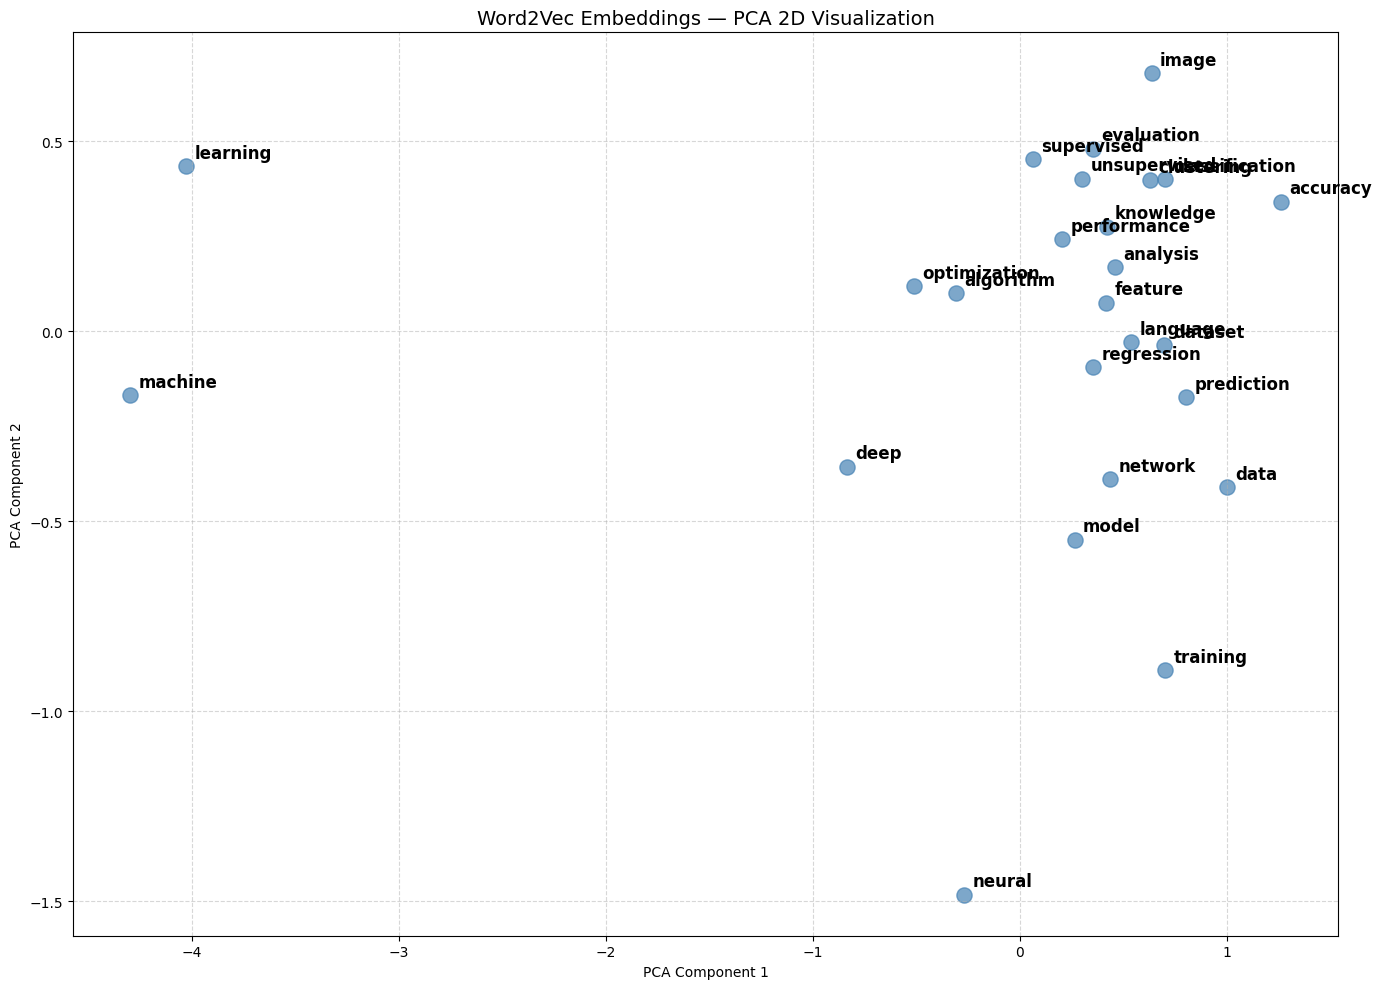

✅ PCA scatter plot saved!

COSINE SIMILARITY BETWEEN WORD PAIRS
Word 1               Word 2               Similarity
------------------------------------------------------------
  machine              learning                 0.8648
  deep                 neural                   0.9170
  supervised           unsupervised             0.9809
  classification       regression               0.9567
  model                algorithm                0.9235
  data                 dataset                  0.9379
  training             evaluation               0.8842
  language             image                    0.9805


In [7]:
# ============================================================
# QUESTION 3 - Word Embedding Model
# ============================================================

!pip install gensim -q

import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Load Data ---
df = pd.read_csv('semantic_scholar_data.csv')
df = df.head(100)
documents = df['abstract'].dropna().tolist()

# ── Tokenizer ─────────────────────────────────────────────
def tokenize(text):
    text = text.lower()
    tokens = []
    word = ""
    for char in text:
        if char.isalpha() or char == "'":
            word += char
        else:
            if word:
                tokens.append(word)
                word = ""
    if word:
        tokens.append(word)
    return tokens

tokenized_docs = [tokenize(doc) for doc in documents]

# ============================================================
# (1) Train 300-dimensional Word2Vec Model
# ============================================================

model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=300,
    window=5,
    min_count=1,
    workers=4,
    epochs=50
)

print("✅ Word2Vec model trained!")
print(f"   Vocabulary size: {len(model.wv)}")

# ============================================================
# (2) Visualize with PCA - Scatter plot of 25 words
# ============================================================

selected_words = [
    'machine', 'learning', 'model', 'data', 'neural',
    'network', 'prediction', 'training', 'classification',
    'algorithm', 'deep', 'feature', 'accuracy', 'supervised',
    'unsupervised', 'clustering', 'regression', 'optimization',
    'language', 'image', 'performance', 'knowledge', 'analysis',
    'evaluation', 'dataset'
]

# Keep only words in vocabulary
selected_words = [w for w in selected_words if w in model.wv]
print(f"\n✅ Words for visualization: {len(selected_words)}")

# Reduce to 2D with PCA
word_vectors = np.array([model.wv[w] for w in selected_words])
pca = PCA(n_components=2)
reduced = pca.fit_transform(word_vectors)

# Plot
plt.figure(figsize=(14, 10))
plt.scatter(reduced[:, 0], reduced[:, 1], color='steelblue', s=120, alpha=0.7)

for i, word in enumerate(selected_words):
    plt.annotate(word,
                 xy=(reduced[i, 0], reduced[i, 1]),
                 xytext=(6, 6),
                 textcoords='offset points',
                 fontsize=12,
                 fontweight='bold')

plt.title("Word2Vec Embeddings — PCA 2D Visualization", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('word2vec_pca.png', dpi=150)
plt.show()
print("✅ PCA scatter plot saved!")

# ============================================================
# (3) Cosine Similarity Between Word Pairs
# ============================================================

print("\n" + "=" * 60)
print("COSINE SIMILARITY BETWEEN WORD PAIRS")
print("=" * 60)
print(f"{'Word 1':<20} {'Word 2':<20} {'Similarity':>10}")
print("-" * 60)

word_pairs = [
    ('machine', 'learning'),
    ('deep', 'neural'),
    ('supervised', 'unsupervised'),
    ('classification', 'regression'),
    ('model', 'algorithm'),
    ('data', 'dataset'),
    ('training', 'evaluation'),
    ('language', 'image'),
]

for w1, w2 in word_pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        print(f"  {w1:<20} {w2:<20} {sim:>10.4f}")
    else:
        print(f"  ⚠️  '{w1}' or '{w2}' not in vocabulary")

## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [8]:
import pandas as pd

df = pd.read_csv('semantic_scholar_data.csv')
df = df.head(100)
df = df.dropna(subset=['abstract'])

def label_sentiment(text):
    text = text.lower()
    positive_words = ['outperform', 'improvement', 'state-of-the-art',
                      'significant', 'superior', 'effective', 'accurate',
                      'success', 'best', 'novel', 'promising', 'robust',
                      'advance', 'achieve', 'exceed', 'gain', 'benefit']
    negative_words = ['limitation', 'fail', 'poor', 'challenge', 'difficult',
                      'problem', 'issue', 'drawback', 'insufficient',
                      'inadequate', 'worse', 'lack', 'error', 'bias']

    pos_count = sum(1 for w in positive_words if w in text)
    neg_count = sum(1 for w in negative_words if w in text)

    if pos_count > neg_count:
        return 'positive'
    elif neg_count > pos_count:
        return 'negative'
    else:
        return 'neutral'

# Build annotated CSV
annotated_df = pd.DataFrame({
    'document_id': range(1, len(df) + 1),
    'clean_text': df['abstract'].values,
    'sentiment': df['abstract'].apply(label_sentiment).values
})

annotated_df.to_csv('annotated_dataset.csv', index=False)
print(annotated_df['sentiment'].value_counts())
print("\nSample:")
print(annotated_df.head())

sentiment
positive    42
negative    31
neutral     27
Name: count, dtype: int64

Sample:
   document_id                                         clean_text sentiment
0            1  Data science has become increasingly essential...  positive
1            2  Modern biology frequently relies on machine le...  negative
2            3  Learning curves are a concept from social scie...  positive
3            4  Online active learning is a paradigm in machin...  negative
4            5  The ability to explain decisions made by machi...  positive


In [ ]:
https://github.com/jimitxdave/Jimit_INFO5731_Spring2026





# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:
The assignment was a helpful introduction to creating and annotating NLP datasets. The most challenging part was assigning the correct sentiment to texts that were not clearly positive, negative, or neutral. I enjoyed building my own dataset, as it gave practical insight into how training data works. The time provided was reasonable and sufficient to complete the task.